In [ ]:
!cp "/content/drive/MyDrive/balanced_image.zip" "/content/balanced_image.zip"

In [ ]:
!unzip -q "/content/balanced_image.zip" -d "/content/"

In [ ]:
%%writefile model_bce_bn.py
# model_bce_bn.py — Conditional VAE para HAM10000
# Autocodificador Variacional Condicional (CVAE)
# Aquí se define el modelo principal.
# La idea es combinar:
# - compresión de la imagen,
# - representación latente probabilística,
# - y generación condicionada por clase.
#
# Este modelo sirve para reconstruir imágenes y también para generar nuevas
# imágenes de una clase específica de lesión.

import torch
import torch.nn as nn
import torch.nn.functional as F


# =========================
# Constantes del modelo
# =========================

# Usamos 128x128 porque es un tamaño bueno entre calidad visual y costo computacional.
# Más grande aumenta el costo, más pequeño puede perder detalles importantes de la lesión.
IMG_SIZE = 128

# El espacio latente de 128 dimensiones da suficiente capacidad
# para guardar información de la imagen sin hacerlo demasiado grande.
# Si fuera muy pequeño, el modelo perdería detalle;
# si fuera muy grande, el espacio latente sería más difícil de aprender.
LATENT_DIM = 128

# Número de clases del dataset HAM10000.
# Cada clase representa un tipo de lesión de piel.
NUM_CLASSES = 7

# ImageFolder ordena las carpetas alfabéticamente.
# Por eso guardamos el orden esperado de clases.
CLASS_NAMES = ["akiec", "bcc", "bkl", "df", "mel", "nv", "vasc"]

# Descripción médica simple de cada clase.
# Esto ayuda a interpretar el dataset y entender qué representa cada etiqueta.
CLASS_DESCRIPTIONS = {
    "mel":   "Melanoma — cáncer agresivo de melanocitos",
    "nv":    "Nevi melanocíticos — lunares benignos",
    "bcc":   "Carcinoma basocelular — cáncer frecuente, lento",
    "akiec": "Queratosis actínica / Bowen — lesión precancerosa",
    "bkl":   "Queratosis benigna — manchas benignas",
    "df":    "Dermatofibroma — bulto benigno firme",
    "vasc":  "Lesiones vasculares — hemangiomas y similares",
}

# Estos límites se usan para evitar inestabilidad numérica.
# En un VAE es común que logvar, std o z crezcan demasiado y generen NaN o Inf.
LOGVAR_MIN = -6.0
LOGVAR_MAX = 2.0
STD_MAX = 3.0
Z_CLAMP = 10.0


# =========================
# Inicialización de pesos
# =========================

# La inicialización Xavier ayuda a que las capas empiecen con valores estables.
# Esto mejora la convergencia al comienzo del entrenamiento.
def init_weights(module):
    if isinstance(module, (nn.Conv2d, nn.ConvTranspose2d, nn.Linear)):
        nn.init.xavier_normal_(module.weight)
        if module.bias is not None:
            nn.init.zeros_(module.bias)

    # BatchNorm empieza de forma neutra:
    # peso en 1 y sesgo en 0.
    elif isinstance(module, nn.BatchNorm2d):
        nn.init.ones_(module.weight)
        nn.init.zeros_(module.bias)


# =========================
# Bloque residual simple
# =========================

# Este bloque residual sirve para conservar información mientras la red aprende.
# La idea es que la salida no dependa solo de las convoluciones nuevas,
# sino también de la entrada original.
#
# Esto ayuda a:
# - mejorar el flujo de gradiente,
# - hacer la red más estable,
# - y evitar que se pierda información importante.
class ResBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()

        self.block = nn.Sequential(
            nn.Conv2d(channels, channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(channels),
            nn.ReLU(inplace=True),

            nn.Conv2d(channels, channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(channels),
        )

    def forward(self, x):
        # Se suma la entrada con la salida del bloque.
        # Esa suma residual ayuda a que la red no pierda la señal original.
        return F.relu(x + self.block(x), inplace=True)


# =========================
# Encoder
# =========================

# El encoder se encarga de comprimir la imagen.
# Va reduciendo la resolución espacial y aumentando la cantidad de canales.
#
# Arquitectura:
# - 128x128 -> 64x64 -> 32x32 -> 16x16 -> 8x8
# - luego se aplana la representación
# - y se generan mu y logvar
#
# En un VAE no se guarda solo un vector fijo,
# sino una distribución en el espacio latente.
class Encoder(nn.Module):
    def __init__(self, latent_dim=LATENT_DIM):
        super().__init__()

        self.conv = nn.Sequential(
            # 128x128x3 -> 64x64x32
            nn.Conv2d(3, 32, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            ResBlock(32),

            # 64x64x32 -> 32x32x64
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            ResBlock(64),

            # 32x32x64 -> 16x16x128
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            ResBlock(128),

            # 16x16x128 -> 8x8x256
            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
        )

        # Después de las convoluciones tenemos un mapa 8x8x256.
        # Eso se aplana antes de pasar a capas fully connected.
        self.flatten_dim = 256 * 8 * 8

        # El VAE necesita dos salidas:
        # - mu: centro de la distribución
        # - logvar: incertidumbre de esa distribución
        self.fc_mu = nn.Linear(self.flatten_dim, latent_dim)
        self.fc_logvar = nn.Linear(self.flatten_dim, latent_dim)

        # Aplicamos la inicialización definida arriba.
        self.apply(init_weights)

        # Empezar con varianza pequeña ayuda a que el muestreo no sea caótico al inicio.
        nn.init.constant_(self.fc_logvar.bias, -2.0)

    def forward(self, x):
        # La imagen pasa por el extractor convolucional.
        h = self.conv(x)
        h = h.view(h.size(0), -1)

        # Sacamos la media de la distribución latente.
        mu = self.fc_mu(h)

        # Sacamos la log-varianza y la acotamos para estabilidad.
        logvar = self.fc_logvar(h)
        logvar = torch.clamp(logvar, min=LOGVAR_MIN, max=LOGVAR_MAX)

        return mu, logvar


# =========================
# Decoder
# =========================

# El decoder hace lo contrario al encoder:
# toma el vector latente y reconstruye la imagen.
#
# Además es condicional:
# recibe la clase de la lesión como embedding para guiar la generación.
# Eso hace que el modelo no genere imágenes "genéricas",
# sino imágenes asociadas a una clase concreta.
class Decoder(nn.Module):
    def __init__(self, latent_dim=LATENT_DIM, num_classes=NUM_CLASSES):
        super().__init__()

        # Convertimos la clase en un embedding denso.
        # Así la red no trabaja con la etiqueta como simple número.
        self.class_embed = nn.Embedding(num_classes, 32)

        # Unimos z + embedding de la clase.
        # Esa mezcla le da contexto semántico al decoder.
        self.fc = nn.Linear(latent_dim + 32, 256 * 8 * 8)

        self.deconv = nn.Sequential(
            # Mantenemos información inicial antes de empezar a subir resolución.
            ResBlock(256),

            # 8x8x256 -> 16x16x128
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            ResBlock(128),

            # 16x16x128 -> 32x32x64
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            ResBlock(64),

            # 32x32x64 -> 64x64x32
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            ResBlock(32),

            # 64x64x32 -> 128x128x3
            # La última capa devuelve logits, no sigmoid.
            # Eso permite usar BCEWithLogitsLoss de forma más estable.
            nn.ConvTranspose2d(32, 3, kernel_size=4, stride=2, padding=1),
        )

        self.apply(init_weights)

    def forward(self, z, class_label):
        # Convertimos la clase en embedding.
        ce = self.class_embed(class_label)

        # Concatenamos el vector latente con la clase.
        zc = torch.cat([z, ce], dim=1)

        # Expandimos a un mapa de características.
        h = self.fc(zc)
        h = h.view(h.size(0), 256, 8, 8)

        # Obtenemos la imagen reconstruida en forma de logits.
        logits = self.deconv(h)
        return logits


# =========================
# CVAE completo
# =========================

# Aquí se une todo el modelo:
# encoder + reparametrización + decoder.
#
# Esta clase representa el modelo final que se usa para entrenar,
# reconstruir, generar e interpolar imágenes.
class ConditionalVAE(nn.Module):
    def __init__(self, latent_dim=LATENT_DIM, num_classes=NUM_CLASSES, beta=1.0):
        super().__init__()

        self.latent_dim = latent_dim
        self.beta = beta

        self.encoder = Encoder(latent_dim)
        self.decoder = Decoder(latent_dim, num_classes)

    # La reparametrización es la parte clave del VAE.
    # En vez de muestrear directamente de una distribución no diferenciable,
    # usamos:
    # z = mu + eps * std
    #
    # mu es la media del espacio latente.
    # std es la desviación estándar.
    # eps es un ruido aleatorio tomado de una distribución normal estándar, normalmente N(0,1).
    # z es el vector latente final que se manda al decoder.
    #
    # Así el muestreo se vuelve entrenable con backpropagation.
    def reparametrize(self, mu, logvar, sample=True):
        # En validación podemos usar mu directo para una reconstrucción determinista.
        if not sample:
            return torch.clamp(mu, -Z_CLAMP, Z_CLAMP)

        # Convertimos logvar a desviación estándar.
        std = torch.exp(0.5 * logvar)
        std = torch.clamp(std, max=STD_MAX)

        # Ruido gaussiano.
        eps = torch.randn_like(std)

        # Muestreo reparametrizado.
        z = mu + eps * std
        z = torch.clamp(z, -Z_CLAMP, Z_CLAMP)

        return z

    def forward(self, x, label, sample=True):
        # El encoder extrae la distribución latente.
        mu, logvar = self.encoder(x)

        # Muestreamos o usamos mu directo según el modo.
        z = self.reparametrize(mu, logvar, sample=sample)

        # El decoder reconstruye usando z y la clase.
        x_logits = self.decoder(z, label)

        return x_logits, mu, logvar

    # La función de pérdida combina dos ideas:
    #
    # 1) Reconstrucción:
    #    hace que la imagen generada se parezca a la original.
    #
    # 2) KL Divergence:
    #    obliga al espacio latente a parecerse a una distribución normal.
    #
    # Esa combinación es la base de un VAE.
    def loss(self, x, x_logits, mu, logvar, beta=None):
        if beta is None:
            beta = self.beta

        B = x.size(0)

        x_f = x.float()
        logits_f = x_logits.float()
        mu_f = mu.float()
        logvar_f = logvar.float()

        # BCEWithLogitsLoss se usa porque el decoder devuelve logits.
        # Esto es más estable que aplicar sigmoid primero y luego BCE.
        #
        # Además las imágenes deben estar en [0, 1],
        # por eso en el entrenamiento no usamos Normalize().
        recon_loss = F.binary_cross_entropy_with_logits(
            logits_f,
            x_f,
            reduction="sum",
        ) / B

        # KL divergence:
        # mide qué tan lejos está la distribución latente de una normal.
        # Esto hace que el espacio latente sea más ordenado y generativo.
        kl_loss = 0.5 * torch.sum(
            logvar_f.exp() + mu_f.pow(2) - 1.0 - logvar_f
        ) / B

        total = recon_loss + beta * kl_loss

        return total, recon_loss, kl_loss

    @torch.no_grad()
    def generate(self, class_label, n=1, device="cpu", temperature=1.0):
        # Generación de imágenes nuevas.
        # Se muestrea un z aleatorio y se condiciona por la clase.
        self.eval()

        label = torch.full(
            size=(n,),
            fill_value=int(class_label),
            dtype=torch.long,
            device=device,
        )

        # Temperature controla qué tan dispersa es la generación.
        # Valores más altos dan más variedad, pero pueden hacer la imagen menos estable.
        z = torch.randn(n, self.latent_dim, device=device) * temperature
        z = torch.clamp(z, -Z_CLAMP, Z_CLAMP)

        logits = self.decoder(z, label)

        # Aplicamos sigmoid solo al final para convertir logits a [0, 1].
        return torch.sigmoid(logits)

    @torch.no_grad()
    def reconstruct(self, x, label):
        # Reconstrucción determinista.
        # Aquí usamos mu directo para ver la salida más estable del modelo.
        self.eval()

        mu, logvar = self.encoder(x)
        z = self.reparametrize(mu, logvar, sample=False)

        logits = self.decoder(z, label)
        return torch.sigmoid(logits), mu

    @torch.no_grad()
    def interpolate(self, x1, label1, x2, label2, steps=8, device="cpu"):
        # Interpolación en el espacio latente.
        # Sirve para ver si el modelo aprendió un espacio continuo.
        self.eval()

        mu1, _ = self.encoder(x1)
        mu2, _ = self.encoder(x2)

        alphas = torch.linspace(0, 1, steps, device=device)

        results = []

        for a in alphas:
            # Mezclamos los dos latentes para crear transiciones suaves.
            z = (1.0 - a) * mu1 + a * mu2
            z = torch.clamp(z, -Z_CLAMP, Z_CLAMP)

            # Se decodifica usando la clase del primer ejemplo.
            logits = self.decoder(z, label1)
            results.append(torch.sigmoid(logits))

        return torch.cat(results, dim=0)


# =========================
# Prueba rápida
# =========================

# Esta sección sirve como prueba mínima para verificar que:
# - el forward funciona,
# - la loss es finita,
# - la generación produce tensores válidos,
# - y el modelo no tiene errores de forma.
if __name__ == "__main__":
    device = "cuda" if torch.cuda.is_available() else "cpu"

    model = ConditionalVAE(latent_dim=128, num_classes=7, beta=1.0).to(device)

    # Datos de prueba aleatorios.
    # Se usa este tamaño porque coincide con el formato real esperado del dataset.
    x = torch.rand(4, 3, 128, 128, device=device)
    label = torch.randint(0, 7, (4,), device=device)

    x_logits, mu, logvar = model(x, label, sample=True)
    loss, recon, kl = model.loss(x, x_logits, mu, logvar)

    print(f"Input:    {x.shape}  min={x.min():.3f}  max={x.max():.3f}")
    print(f"Logits:   {x_logits.shape}  min={x_logits.min():.3f}  max={x_logits.max():.3f}")
    print(f"mu:       min={mu.min():.3f}  max={mu.max():.3f}")
    print(f"logvar:   min={logvar.min():.3f}  max={logvar.max():.3f}")
    print(f"Loss:     total={loss:.4f}  recon={recon:.4f}  kl={kl:.4f}")

    assert torch.isfinite(loss), "NaN/Inf en loss"
    assert torch.isfinite(x_logits).all(), "NaN/Inf en logits"
    assert torch.isfinite(mu).all(), "NaN/Inf en mu"
    assert torch.isfinite(logvar).all(), "NaN/Inf en logvar"

    gen = model.generate(class_label=0, n=4, device=device)
    print(f"Generated: {gen.shape}  min={gen.min():.3f}  max={gen.max():.3f}")

    total_params = sum(p.numel() for p in model.parameters())
    print(f"Parámetros: {total_params:,}")
    print("✅ Test pasado")


Overwriting model_bce_bn.py


In [ ]:
%%writefile train_bce_bn.py
# train_bce_bn.py — Entrenamiento para model_bce_bn.py
# Aquí se define todo el flujo de entrenamiento del CVAE.
#
# Este archivo no solo entrena la red:
# también prepara los datos, controla estabilidad numérica,
# guarda checkpoints, evalúa en validación y genera muestras.
#
# La idea del diseño es que el entrenamiento sea:
# - estable,
# - reproducible,
# - fácil de reanudar,
# - y fácil de monitorear.

import os
import time
import shutil
import argparse
import numpy as np

import torch
import torch.backends.cudnn as cudnn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.datasets import ImageFolder
from PIL import Image

from model_bce_bn import ConditionalVAE, IMG_SIZE, LATENT_DIM


# =========================
# Argumentos
# =========================

# Aquí se definen los parámetros que controlan todo el entrenamiento.
# Se usan valores por defecto razonables para que el script funcione sin cambiar mucho,
# pero se pueden ajustar según el hardware o el experimento.
def parse_args():
    p = argparse.ArgumentParser()

    # Carpetas del dataset
    p.add_argument("--train_dir", default="./balanced_image/training")
    p.add_argument("--val_dir", default="./balanced_image/testing")

    # Salida principal
    p.add_argument(
        "--output_dir",
        default="./output_cvae_bce_bn",
        help="Directorio nuevo para no sobreescribir resultados anteriores.",
    )

    # Carpeta opcional de Drive para backups
    p.add_argument(
        "--drive_dir",
        default=None,
        help="Carpeta opcional en Drive para backups.",
    )

    # Epochs:
    # Se usa 50 como punto de partida porque suele ser suficiente
    # En datasets más difíciles esto puede subir.
    p.add_argument("--epochs", type=int, default=50)

    # Batch size:
    # 64 es un valor intermedio bueno para equilibrar estabilidad y uso de memoria.
    p.add_argument("--batch_size", type=int, default=64)

    # Learning rate:
    # 1e-4 es una elección conservadora y estable para Adam.
    p.add_argument("--lr", type=float, default=1e-4)

    # Tamaño del latente y beta del VAE
    p.add_argument("--latent_dim", type=int, default=LATENT_DIM)
    p.add_argument("--beta", type=float, default=1.0)

    # Warmup de KL:
    # Se deja en 0 por defecto para empezar simple,
    # pero se puede activar si al inicio el KL domina demasiado.
    p.add_argument("--kl_warmup_epochs", type=int, default=0)

    # Tamaño de imagen y workers
    p.add_argument("--img_size", type=int, default=IMG_SIZE)
    p.add_argument("--num_workers", type=int, default=4)

    # Reanudar entrenamiento
    p.add_argument("--resume", default=None)
    p.add_argument("--auto_resume", action="store_true")

    # Cada cuántas épocas guardar checkpoint numerado
    p.add_argument("--save_every", type=int, default=5)

    # Opciones para acelerar o depurar
    p.add_argument("--no_amp", action="store_true")
    p.add_argument("--debug", action="store_true")

    return p.parse_args()


# =========================
# Helpers
# =========================

# Esta parte prepara el entorno para entrenamiento.
# Si debug está activo, se prioriza detectar errores antes que velocidad.
def setup_runtime(debug):
    if debug:
        os.environ["CUDA_LAUNCH_BLOCKING"] = "1"
        torch.autograd.set_detect_anomaly(True)
        cudnn.deterministic = True
        cudnn.benchmark = False
        print("⚠️  DEBUG activo: AMP desactivado, anomaly detection activo.\n")
    else:
        cudnn.benchmark = True


# Sirve para ver cuánta VRAM se está usando.
# Útil cuando el entrenamiento empieza a acercarse al límite de memoria.
def log_vram(device):
    if device.type == "cuda":
        alloc = torch.cuda.memory_allocated(device) / 1024**2
        reserved = torch.cuda.memory_reserved(device) / 1024**2
        print(f"  [DEBUG] VRAM: {alloc:.0f} MB alloc / {reserved:.0f} MB reserved")


# Imprime estadísticas básicas de un tensor.
# Esto ayuda a detectar NaN, Inf o valores fuera de rango.
def print_tensor_stats(name, x):
    with torch.no_grad():
        print(
            f"    {name:<8} finite={torch.isfinite(x).all().item()} "
            f"min={x.min().item():.6f} "
            f"max={x.max().item():.6f} "
            f"mean={x.mean().item():.6f}"
        )


# Warmup de KL:
# al comienzo del entrenamiento el KL puede ser demasiado fuerte.
# Subir beta poco a poco permite que primero aprenda a reconstruir,
# y después a regularizar el espacio latente.
def get_beta_for_epoch(epoch, target_beta, warmup_epochs):
    if warmup_epochs <= 0:
        return target_beta

    progress = min(1.0, epoch / float(warmup_epochs))
    return target_beta * progress


# Esta función ayuda a acceder al modelo real cuando está envuelto
# por DataParallel, compile o alguna otra capa.
def _raw(model):
    return getattr(model, "_orig_mod", model)


# =========================
# Dataset
# =========================

# Dataset personalizado para imágenes de piel.
# La idea es:
# - leer carpetas por clase,
# - filtrar clases no deseadas,
# - aplicar augmentations,
# - y dejar las imágenes en [0, 1] sin Normalize().
#
# No usamos Normalize porque el decoder y la loss trabajan con
# Binary Cross Entropy with Logits (BCEWithLogitsLoss) para clasificacion binaria,
# que espera targets entre 0 y 1.

#  Estructura esperada:
#
#    root_dir/
#      akiec/
#      bcc/
#      bkl/
#      df/
#      mel/
#      nv/
#      vasc/
#      normal_skin/   opcional, se excluye
#
#  IMPORTANTE:
#    No usamos Normalize().
#    Las imágenes quedan en [0, 1].
class SkinDataset(Dataset):
    def __init__(self, root_dir, img_size=128, augment=True, exclude_classes=None):
        if exclude_classes is None:
            exclude_classes = []

        if not os.path.isdir(root_dir):
            raise FileNotFoundError(f"No existe el directorio: {root_dir}")

        aug_transforms = []

        # Augmentation:
        # aumenta la variedad de imágenes sin cambiar la clase real.
        # Esto ayuda a generalizar mejor y reduce sobreajuste.
        if augment:
            aug_transforms = [
                transforms.RandomHorizontalFlip(),
                transforms.RandomVerticalFlip(),
                transforms.RandomRotation(15),
                transforms.ColorJitter(
                    brightness=0.20,
                    contrast=0.20,
                    saturation=0.10,
                    hue=0.02,
                ),
            ]

        self.transform = transforms.Compose(
            [
                transforms.Resize((img_size, img_size)),
                *aug_transforms,
                transforms.ToTensor(),
            ]
        )

        # ImageFolder lee el dataset por carpetas.
        full_dataset = ImageFolder(root=root_dir)

        # Filtramos clases no deseadas, por ejemplo normal_skin.
        filtered_samples = [
            (path, label)
            for path, label in full_dataset.samples
            if full_dataset.classes[label] not in exclude_classes
        ]

        if len(filtered_samples) == 0:
            raise RuntimeError(f"No se encontraron imágenes válidas en {root_dir}")

        # Nos quedamos solo con las clases que realmente existen después del filtro.
        kept_classes = sorted(
            set(full_dataset.classes[label] for _, label in filtered_samples)
        )

        # Reindexamos clases para que train y val tengan el mismo mapeo.
        self.class_to_idx = {cls: i for i, cls in enumerate(kept_classes)}
        self.idx_to_class = {i: cls for cls, i in self.class_to_idx.items()}

        self.samples = [
            (path, self.class_to_idx[full_dataset.classes[label]])
            for path, label in filtered_samples
        ]

        self.targets = [label for _, label in self.samples]

        # Contamos imágenes por clase.
        class_counts = np.bincount(self.targets, minlength=len(kept_classes))

        if np.any(class_counts == 0):
            raise RuntimeError(f"Hay clases sin imágenes: {class_counts}")

        # WeightedRandomSampler usa pesos inversos a la frecuencia.
        # Esto ayuda cuando el dataset está desbalanceado.
        weights = 1.0 / class_counts
        self.sample_weights = torch.DoubleTensor(weights[self.targets])

        print(f"\nDataset: {root_dir}")
        print(f"Clases ({len(kept_classes)}): {self.class_to_idx}")
        print(f"Total: {len(self.samples)} imágenes")

        for cls, idx in self.class_to_idx.items():
            print(f"  {cls:<10} {class_counts[idx]:>6}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]

        try:
            img = Image.open(path).convert("RGB")
        except Exception as e:
            raise RuntimeError(f"Error leyendo imagen {path}: {e}")

        img = self.transform(img)
        label = torch.tensor(label, dtype=torch.long)

        return img, label


# =========================
# DataLoader
# =========================

# Creamos el loader con opciones pensadas para rendimiento.
# pin_memory ayuda cuando se usa GPU.
# persistent_workers y prefetch_factor pueden acelerar la carga de datos.
def make_loader(dataset, batch_size, num_workers, use_amp, sampler=None, shuffle=False):
    kwargs = {
        "batch_size": batch_size,
        "num_workers": num_workers,
        "pin_memory": use_amp,
        "shuffle": shuffle if sampler is None else False,
        "sampler": sampler,
    }

    if num_workers > 0:
        kwargs["persistent_workers"] = True
        kwargs["prefetch_factor"] = 2

    return DataLoader(dataset, **kwargs)


# =========================
# Checkpoints
# =========================

# Guardamos el estado completo del entrenamiento:
# modelo, optimizador, scheduler y scaler.
# Esto permite reanudar sin perder progreso.
def save_checkpoint(
    path,
    epoch,
    model,
    optimizer,
    scheduler,
    scaler,
    best_val,
    class_names,
    args,
):
    os.makedirs(os.path.dirname(path), exist_ok=True)

    torch.save(
        {
            "epoch": epoch,
            "model": _raw(model).state_dict(),
            "optimizer": optimizer.state_dict(),
            "scheduler": scheduler.state_dict() if scheduler is not None else None,
            "scaler": scaler.state_dict() if scaler is not None else None,
            "best_val": best_val,
            "class_names": class_names,
            "args": vars(args),
        },
        path,
    )


# Carga un checkpoint y recupera el estado para seguir entrenando.
def load_checkpoint(path, model, optimizer, scheduler, scaler, device):
    if not os.path.isfile(path):
        raise FileNotFoundError(f"No existe checkpoint: {path}")

    ckpt = torch.load(path, map_location=device, weights_only=False)

    _raw(model).load_state_dict(ckpt["model"])

    if optimizer is not None and ckpt.get("optimizer") is not None:
        optimizer.load_state_dict(ckpt["optimizer"])

    if scheduler is not None and ckpt.get("scheduler") is not None:
        scheduler.load_state_dict(ckpt["scheduler"])

    if scaler is not None and ckpt.get("scaler") is not None:
        scaler.load_state_dict(ckpt["scaler"])

    start_epoch = int(ckpt["epoch"]) + 1
    best_val = float(ckpt.get("best_val", float("inf")))

    print(f"✅ Checkpoint cargado: {path}")
    print(f"   Siguiente epoch: {start_epoch}")
    print(f"   Mejor val: {best_val:.4f}")

    return start_epoch, best_val


# Backup opcional a Drive.
# Esto es útil si se está entrenando en un entorno temporal
# y no se quiere perder el trabajo.
def backup_to_drive(src, drive_dir, name):
    if not drive_dir:
        return

    try:
        os.makedirs(drive_dir, exist_ok=True)
        dst = os.path.join(drive_dir, name)
        shutil.copy2(src, dst)
        print(f"  → Drive backup: {dst}")
    except Exception as e:
        print(f"  ⚠️ Drive backup falló: {e}")


# =========================
# Train / Val
# =========================

# Una época de entrenamiento.
# Aquí se hace:
# - forward,
# - cálculo de pérdida,
# - backward,
# - clipping de gradientes,
# - y update del optimizador.
#
# Se usa gradient clipping porque en modelos generativos
# los gradientes pueden crecer demasiado y volver inestable el entrenamiento.
def train_epoch(model, loader, optimizer, device, scaler, use_amp, debug, beta):
    model.train()

    total_loss = 0.0
    total_recon = 0.0
    total_kl = 0.0
    skipped = 0
    first = True

    for batch_idx, (imgs, labels) in enumerate(loader):
        imgs = imgs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        # BCEWithLogitsLoss necesita targets en [0, 1].
        imgs = torch.clamp(imgs, 0.0, 1.0)

        optimizer.zero_grad(set_to_none=True)

        # AMP acelera el entrenamiento en GPU y reduce uso de memoria.
        with torch.amp.autocast(device_type=device.type, enabled=use_amp):
            x_logits, mu, logvar = model(imgs, labels, sample=True)
            loss, recon, kl = model.loss(imgs, x_logits, mu, logvar, beta=beta)

        # Si algo sale mal numéricamente, se evita hacer step.
        if not torch.isfinite(loss):
            skipped += 1
            print(f"\n⛔ Batch {batch_idx}: loss no finita. Se omite.")
            print_tensor_stats("imgs", imgs)
            print_tensor_stats("logits", x_logits)
            print_tensor_stats("mu", mu)
            print_tensor_stats("logvar", logvar)
            optimizer.zero_grad(set_to_none=True)
            continue

        if use_amp:
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)

            # Clipping para evitar explosión de gradientes.
            grad_norm = torch.nn.utils.clip_grad_norm_(
                _raw(model).parameters(),
                max_norm=1.0,
                error_if_nonfinite=False,
            )

            if not torch.isfinite(grad_norm):
                skipped += 1
                print(f"\n⛔ Batch {batch_idx}: grad_norm no finito. Se omite step.")
                optimizer.zero_grad(set_to_none=True)
                scaler.update()
                continue

            scaler.step(optimizer)
            scaler.update()

        else:
            loss.backward()

            grad_norm = torch.nn.utils.clip_grad_norm_(
                _raw(model).parameters(),
                max_norm=1.0,
                error_if_nonfinite=False,
            )

            if not torch.isfinite(grad_norm):
                skipped += 1
                print(f"\n⛔ Batch {batch_idx}: grad_norm no finito. Se omite step.")
                optimizer.zero_grad(set_to_none=True)
                continue

            optimizer.step()

        total_loss += loss.item()
        total_recon += recon.item()
        total_kl += kl.item()

        # Debug solo en el primer batch para no saturar la salida.
        if debug and first:
            print("    [DEBUG TRAIN]")
            print_tensor_stats("imgs", imgs)
            print_tensor_stats("logits", x_logits)
            print_tensor_stats("probs", torch.sigmoid(x_logits))
            print_tensor_stats("mu", mu)
            print_tensor_stats("logvar", logvar)
            print(
                f"    loss={loss.item():.4f} "
                f"recon={recon.item():.4f} "
                f"kl={kl.item():.4f} "
                f"beta={beta:.4f} "
                f"grad_norm={float(grad_norm):.4f}"
            )
            first = False

    n = max(1, len(loader) - skipped)

    return (
        total_loss / n,
        total_recon / n,
        total_kl / n,
        skipped,
    )


# Validación sin backprop.
# Aquí se usa sample=False para que la reconstrucción sea determinista,
# usando mu directo en lugar de muestreo aleatorio.
@torch.no_grad()
def val_epoch(model, loader, device, use_amp, debug, beta):
    model.eval()

    total_loss = 0.0
    total_recon = 0.0
    total_kl = 0.0
    skipped = 0
    first = True

    for batch_idx, (imgs, labels) in enumerate(loader):
        imgs = imgs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        imgs = torch.clamp(imgs, 0.0, 1.0)

        with torch.amp.autocast(device_type=device.type, enabled=use_amp):
            x_logits, mu, logvar = model(imgs, labels, sample=False)
            loss, recon, kl = model.loss(imgs, x_logits, mu, logvar, beta=beta)

        if not torch.isfinite(loss):
            skipped += 1
            print(f"\n⛔ VAL batch {batch_idx}: loss no finita. Se omite.")
            print_tensor_stats("imgs", imgs)
            print_tensor_stats("logits", x_logits)
            print_tensor_stats("mu", mu)
            print_tensor_stats("logvar", logvar)
            continue

        total_loss += loss.item()
        total_recon += recon.item()
        total_kl += kl.item()

        if debug and first:
            print("    [DEBUG VAL]")
            print_tensor_stats("imgs", imgs)
            print_tensor_stats("logits", x_logits)
            print_tensor_stats("probs", torch.sigmoid(x_logits))
            print_tensor_stats("mu", mu)
            print_tensor_stats("logvar", logvar)
            print(
                f"    val_loss={loss.item():.4f} "
                f"val_recon={recon.item():.4f} "
                f"val_kl={kl.item():.4f} "
                f"beta={beta:.4f}"
            )
            first = False

    n = max(1, len(loader) - skipped)

    return (
        total_loss / n,
        total_recon / n,
        total_kl / n,
        skipped,
    )


# =========================
# Muestras
# =========================

# Generar muestras durante el entrenamiento permite revisar
# si el modelo está aprendiendo formas reales por clase.
# Guardamos una versión normal y otra normalizada para inspección visual.
@torch.no_grad()
def save_samples(model, class_names, device, output_dir, epoch, n_per_class=4):
    import torchvision.utils as vutils

    os.makedirs(output_dir, exist_ok=True)

    model.eval()

    all_imgs = []

    # Generamos varias imágenes por clase para comparar cómo cambia la salida.
    for class_idx in range(len(class_names)):
        imgs = model.generate(
            class_label=class_idx,
            n=n_per_class,
            device=device,
            temperature=0.8,
        )

        all_imgs.append(imgs.cpu())

    imgs = torch.cat(all_imgs, dim=0)

    # Imagen normal: respeta el rango [0, 1].
    path = os.path.join(output_dir, f"samples_epoch_{epoch:03d}.png")
    vutils.save_image(
        imgs,
        path,
        nrow=n_per_class,
        padding=2,
    )

    # Imagen normalizada: útil para ver contraste visual, aunque no sea la salida real.
    path_norm = os.path.join(output_dir, f"samples_epoch_{epoch:03d}_normalized.png")
    grid_norm = vutils.make_grid(
        imgs,
        nrow=n_per_class,
        normalize=True,
        padding=2,
    )
    vutils.save_image(grid_norm, path_norm)

    print(f"  → Muestras: {path}")
    print(f"  → Muestras normalizadas: {path_norm}")


# =========================
# Main
# =========================

# Aquí se junta todo:
# - se leen argumentos,
# - se preparan datos,
# - se crea el modelo,
# - se entrena época por época,
# - y se guardan resultados.
def main():
    args = parse_args()

    # Usamos GPU si está disponible.
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    setup_runtime(args.debug)

    # AMP solo se usa en CUDA, y se desactiva si estamos en debug.
    use_amp = (device.type == "cuda") and (not args.no_amp) and (not args.debug)

    print(f"Dispositivo: {device} | AMP: {use_amp}")

    os.makedirs(args.output_dir, exist_ok=True)

    # =========================
    # Dataset
    # =========================

    # Train con augmentations para generalizar mejor.
    train_ds = SkinDataset(
        args.train_dir,
        img_size=args.img_size,
        augment=True,
        exclude_classes=["normal_skin"],
    )

    # Val sin augment para medir el comportamiento real del modelo.
    val_ds = SkinDataset(
        args.val_dir,
        img_size=args.img_size,
        augment=False,
        exclude_classes=["normal_skin"],
    )

    class_names = list(train_ds.class_to_idx.keys())
    num_classes = len(class_names)

    print(f"\nClases train ({num_classes}): {class_names}")
    print(f"Clases val: {list(val_ds.class_to_idx.keys())}")

    # Es importante que train y val usen exactamente el mismo mapeo de clases.
    if train_ds.class_to_idx != val_ds.class_to_idx:
        raise RuntimeError(
            "El mapeo de clases train/val no coincide. "
            f"train={train_ds.class_to_idx}, val={val_ds.class_to_idx}"
        )

    # Sampler balanceado para compensar clases con pocas imágenes.
    sampler = torch.utils.data.WeightedRandomSampler(
        weights=train_ds.sample_weights,
        num_samples=len(train_ds),
        replacement=True,
    )

    train_loader = make_loader(
        train_ds,
        batch_size=args.batch_size,
        num_workers=args.num_workers,
        use_amp=use_amp,
        sampler=sampler,
        shuffle=False,
    )

    val_loader = make_loader(
        val_ds,
        batch_size=args.batch_size,
        num_workers=args.num_workers,
        use_amp=use_amp,
        sampler=None,
        shuffle=False,
    )

    # =========================
    # Modelo
    # =========================

    model = ConditionalVAE(
        latent_dim=args.latent_dim,
        num_classes=num_classes,
        beta=args.beta,
    ).to(device)

    total_params = sum(p.numel() for p in model.parameters())
    print(f"Parámetros: {total_params:,}")

    # =========================
    # Optimizer
    # =========================

    # Adam suele funcionar bien en modelos generativos.
    # Se usa weight decay pequeño para regularización ligera.
    optimizer = optim.Adam(
        model.parameters(),
        lr=args.lr,
        weight_decay=1e-5,
    )

    # ReduceLROnPlateau baja el learning rate si la validación deja de mejorar.
    # Esto ayuda a afinar el entrenamiento cuando el modelo se estanca.
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        patience=5,
        factor=0.5,
    )

    # GradScaler acompaña AMP para mantener estabilidad en precisión mixta.
    scaler = torch.amp.GradScaler(
        device.type,
        enabled=use_amp,
        init_scale=1024,
        growth_interval=2000,
    )

    # =========================
    # Resume
    # =========================

    start_epoch = 1
    best_val = float("inf")

    latest_path = os.path.join(args.output_dir, "latest.pt")
    resume_path = args.resume

    # Si se activó auto_resume, usamos latest.pt si ya existe.
    if resume_path is None and args.auto_resume and os.path.exists(latest_path):
        resume_path = latest_path

    if resume_path:
        start_epoch, best_val = load_checkpoint(
            resume_path,
            model,
            optimizer,
            scheduler,
            scaler,
            device,
        )
    else:
        print("Iniciando desde cero.")

    # =========================
    # Logs
    # =========================

    # Guardamos las métricas en CSV para poder comparar experimentos después.
    log_path = os.path.join(args.output_dir, "training_log.csv")

    if not os.path.exists(log_path) or start_epoch == 1:
        with open(log_path, "w") as f:
            f.write(
                "epoch,beta,train_loss,train_recon,train_kl,"
                "val_loss,val_recon,val_kl,lr,elapsed_s,"
                "skipped_train,skipped_val\n"
            )

    best_path = os.path.join(args.output_dir, "best_model.pt")

    # =========================
    # Loop principal
    # =========================

    # Entrenamos por épocas para poder monitorear el avance,
    # guardar checkpoints y comparar train vs val.
    for epoch in range(start_epoch, args.epochs + 1):
        t0 = time.time()

        # Si hay warmup, beta sube poco a poco.
        beta_now = get_beta_for_epoch(
            epoch=epoch,
            target_beta=args.beta,
            warmup_epochs=args.kl_warmup_epochs,
        )

        model.beta = beta_now

        if args.debug:
            print(f"\n── Epoch {epoch} TRAIN ──")

        tr_loss, tr_recon, tr_kl, skipped_train = train_epoch(
            model=model,
            loader=train_loader,
            optimizer=optimizer,
            device=device,
            scaler=scaler,
            use_amp=use_amp,
            debug=args.debug,
            beta=beta_now,
        )

        if args.debug:
            print(f"\n── Epoch {epoch} VAL ──")

        vl_loss, vl_recon, vl_kl, skipped_val = val_epoch(
            model=model,
            loader=val_loader,
            device=device,
            use_amp=use_amp,
            debug=args.debug,
            beta=beta_now,
        )

        # No castigamos el scheduler durante warmup.
        if epoch > args.kl_warmup_epochs:
            scheduler.step(vl_loss)

        lr = optimizer.param_groups[0]["lr"]
        elapsed = time.time() - t0

        print(
            f"Epoch {epoch:03d}/{args.epochs} | "
            f"beta={beta_now:.4f} | "
            f"Train={tr_loss:.4f} "
            f"(recon={tr_recon:.4f}, kl={tr_kl:.4f}) | "
            f"Val={vl_loss:.4f} "
            f"(recon={vl_recon:.4f}, kl={vl_kl:.4f}) | "
            f"LR={lr:.2e} | "
            f"{elapsed:.1f}s | "
            f"skip T/V={skipped_train}/{skipped_val}"
        )

        if args.debug:
            log_vram(device)

        # Guardamos el historial del entrenamiento.
        with open(log_path, "a") as f:
            f.write(
                f"{epoch},{beta_now:.6f},"
                f"{tr_loss:.6f},{tr_recon:.6f},{tr_kl:.6f},"
                f"{vl_loss:.6f},{vl_recon:.6f},{vl_kl:.6f},"
                f"{lr:.8f},{elapsed:.1f},"
                f"{skipped_train},{skipped_val}\n"
            )

        # Mejor modelo:
        # Si hay warmup, empezamos a evaluar el "mejor" después de eso.
        can_update_best = epoch >= max(1, args.kl_warmup_epochs)

        if can_update_best and vl_loss < best_val:
            best_val = vl_loss

            save_checkpoint(
                best_path,
                epoch,
                model,
                optimizer,
                scheduler,
                scaler,
                best_val,
                class_names,
                args,
            )

            print(f"  → Mejor modelo: {best_path} | val={best_val:.4f}")

        # latest se guarda siempre para poder retomar desde el último estado.
        save_checkpoint(
            latest_path,
            epoch,
            model,
            optimizer,
            scheduler,
            scaler,
            best_val,
            class_names,
            args,
        )

        # Cada cierto número de épocas guardamos un checkpoint extra
        # y generamos muestras para revisión visual.
        if epoch % args.save_every == 0:
            ckpt_name = f"ckpt_epoch_{epoch:03d}.pt"
            ckpt_path = os.path.join(args.output_dir, ckpt_name)

            save_checkpoint(
                ckpt_path,
                epoch,
                model,
                optimizer,
                scheduler,
                scaler,
                best_val,
                class_names,
                args,
            )

            print(f"  → Checkpoint: {ckpt_path}")

            # Generamos ejemplos visuales de cada clase.
            save_samples(
                model=model,
                class_names=class_names,
                device=device,
                output_dir=os.path.join(args.output_dir, "samples"),
                epoch=epoch,
                n_per_class=4,
            )

            # Si hay carpeta de Drive, copiamos también las muestras.
            if args.drive_dir:
                local_samples_dir = os.path.join(args.output_dir, "samples")
                drive_samples_dir = os.path.join(args.drive_dir, "samples")
                os.makedirs(drive_samples_dir, exist_ok=True)

                if os.path.isdir(local_samples_dir):
                    for fname in os.listdir(local_samples_dir):
                        if fname.endswith(".png"):
                            shutil.copy2(
                                os.path.join(local_samples_dir, fname),
                                os.path.join(drive_samples_dir, fname),
                            )

                    print(f"  → Samples backup en Drive: {drive_samples_dir}")
                else:
                    print(f"  ⚠ No existe carpeta local de samples: {local_samples_dir}")

            # Backups de checkpoint y logs.
            backup_to_drive(ckpt_path, args.drive_dir, ckpt_name)
            backup_to_drive(latest_path, args.drive_dir, "latest.pt")
            backup_to_drive(best_path, args.drive_dir, "best_model.pt")
            backup_to_drive(log_path, args.drive_dir, "training_log.csv")

    # Backup final al terminar.
    backup_to_drive(best_path, args.drive_dir, "best_model.pt")
    backup_to_drive(latest_path, args.drive_dir, "latest.pt")
    backup_to_drive(log_path, args.drive_dir, "training_log.csv")

    print(f"\n✅ Entrenamiento completo. Mejor val={best_val:.4f}")
    print(f"Resultados en: {args.output_dir}")


if __name__ == "__main__":
    main()


Overwriting train_bce_bn.py


In [ ]:
!python train_bce_bn.py \
  --train_dir "/content/balanced_image/training" \
  --val_dir "/content/balanced_image/testing" \
  --output_dir "/content/output_cvae_bce_bn_fp32" \
  --drive_dir "/content/drive/MyDrive/output_cvae_bce_bn_fp32" \
  --epochs 50 \
  --batch_size 64 \
  --lr 1e-4 \
  --beta 1.0 \
  --num_workers 2 \
  --save_every 5 \
  --no_amp \
  --resume "/content/output_cvae_bce_bn_fp32/latest.pt"

Dispositivo: cuda | AMP: False

Dataset: /content/balanced_image/training
Clases (7): {'akiec': 0, 'bcc': 1, 'bkl': 2, 'df': 3, 'mel': 4, 'nv': 5, 'vasc': 6}
Total: 37257 imágenes
  akiec        5324
  bcc          5328
  bkl          5327
  df           5320
  mel          5324
  nv           5315
  vasc         5319

Dataset: /content/balanced_image/testing
Clases (7): {'akiec': 0, 'bcc': 1, 'bkl': 2, 'df': 3, 'mel': 4, 'nv': 5, 'vasc': 6}
Total: 9316 imágenes
  akiec        1331
  bcc          1332
  bkl          1332
  df           1330
  mel          1332
  nv           1329
  vasc         1330

Clases train (7): ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
Clases val: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
Parámetros: 10,169,955
Iniciando desde cero.
Epoch 001/50 | beta=1.0000 | Train=28047.5825 (recon=27925.0374, kl=122.5451) | Val=28044.5567 (recon=27914.8182, kl=129.7385) | LR=1.00e-04 | 314.9s | skip T/V=0/0
  → Mejor modelo: /content/output_cvae_bce_bn_fp32

In [ ]:
!python train_bce_bn.py \
  --train_dir "/content/balanced_image/training" \
  --val_dir "/content/balanced_image/testing" \
  --output_dir "/content/output_cvae_bce_bn_fp32" \
  --drive_dir "/content/drive/MyDrive/output_cvae_bce_bn_fp32" \
  --epochs 50 \
  --batch_size 64 \
  --lr 1e-4 \
  --beta 1.0 \
  --num_workers 2 \
  --save_every 5 \
  --no_amp \
  --resume "/content/output_cvae_bce_bn_fp32/resume_epoch_025.pt"

Dispositivo: cuda | AMP: False

Dataset: /content/balanced_image/training
Clases (7): {'akiec': 0, 'bcc': 1, 'bkl': 2, 'df': 3, 'mel': 4, 'nv': 5, 'vasc': 6}
Total: 37257 imágenes
  akiec        5324
  bcc          5328
  bkl          5327
  df           5320
  mel          5324
  nv           5315
  vasc         5319

Dataset: /content/balanced_image/testing
Clases (7): {'akiec': 0, 'bcc': 1, 'bkl': 2, 'df': 3, 'mel': 4, 'nv': 5, 'vasc': 6}
Total: 9316 imágenes
  akiec        1331
  bcc          1332
  bkl          1332
  df           1330
  mel          1332
  nv           1329
  vasc         1330

Clases train (7): ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
Clases val: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
Parámetros: 10,169,955
✅ Checkpoint cargado: /content/output_cvae_bce_bn_fp32/resume_epoch_025.pt
   Siguiente epoch: 26
   Mejor val: 27624.5874
Epoch 026/50 | beta=1.0000 | Train=25985.7737 (recon=25873.5921, kl=112.1816) | Val=27610.3777 (recon=27502.8661, 

In [ ]:
!python train_bce_bn.py \
  --train_dir "/content/balanced_image/training" \
  --val_dir "/content/balanced_image/testing" \
  --output_dir "/content/output_cvae_bce_bn_fp32" \
  --drive_dir "/content/drive/MyDrive/output_cvae_bce_bn_fp32" \
  --epochs 50 \
  --batch_size 64 \
  --lr 1e-4 \
  --beta 1.0 \
  --num_workers 2 \
  --save_every 5 \
  --no_amp \
  --resume "/content/output_cvae_bce_bn_fp32/latest.pt"

Dispositivo: cuda | AMP: False

Dataset: /content/balanced_image/training
Clases (7): {'akiec': 0, 'bcc': 1, 'bkl': 2, 'df': 3, 'mel': 4, 'nv': 5, 'vasc': 6}
Total: 37257 imágenes
  akiec        5324
  bcc          5328
  bkl          5327
  df           5320
  mel          5324
  nv           5315
  vasc         5319

Dataset: /content/balanced_image/testing
Clases (7): {'akiec': 0, 'bcc': 1, 'bkl': 2, 'df': 3, 'mel': 4, 'nv': 5, 'vasc': 6}
Total: 9316 imágenes
  akiec        1331
  bcc          1332
  bkl          1332
  df           1330
  mel          1332
  nv           1329
  vasc         1330

Clases train (7): ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
Clases val: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
Parámetros: 10,169,955
✅ Checkpoint cargado: /content/output_cvae_bce_bn_fp32/latest.pt
   Siguiente epoch: 31
   Mejor val: 27608.3280
Epoch 031/50 | beta=1.0000 | Train=25946.2487 (recon=25833.9089, kl=112.3398) | Val=27622.7043 (recon=27511.9190, kl=110.785

In [ ]:
%%writefile regenerate_samples_bce_bn.py
import os
import glob
import torch
import torchvision.utils as vutils

from model_bce_bn import ConditionalVAE


DRIVE_DIR = "/content/drive/MyDrive/output_cvae_bce_bn_fp32"
OUT_DIR = os.path.join(DRIVE_DIR, "regenerated_samples")

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
N_PER_CLASS = 4
TEMPERATURE = 0.8
SEED = 1234


def load_checkpoint(path):
    ckpt = torch.load(path, map_location=DEVICE, weights_only=False)

    class_names = ckpt.get(
        "class_names",
        ["akiec", "bcc", "bkl", "df", "mel", "nv", "vasc"]
    )

    args = ckpt.get("args", {})
    latent_dim = args.get("latent_dim", 128)

    model = ConditionalVAE(
        latent_dim=latent_dim,
        num_classes=len(class_names),
        beta=args.get("beta", 1.0),
    ).to(DEVICE)

    model.load_state_dict(ckpt["model"])
    model.eval()

    return model, class_names, ckpt


@torch.no_grad()
def save_samples_for_checkpoint(ckpt_path):
    name = os.path.splitext(os.path.basename(ckpt_path))[0]

    print(f"Regenerando muestras desde: {name}")

    model, class_names, ckpt = load_checkpoint(ckpt_path)

    imgs = []

    # Seed fija para que sea reproducible desde ahora.
    torch.manual_seed(SEED)

    if DEVICE == "cuda":
        torch.cuda.manual_seed_all(SEED)

    for class_idx in range(len(class_names)):
        generated = model.generate(
            class_label=class_idx,
            n=N_PER_CLASS,
            device=DEVICE,
            temperature=TEMPERATURE,
        ).cpu()

        imgs.append(generated)

    imgs = torch.cat(imgs, dim=0)

    os.makedirs(OUT_DIR, exist_ok=True)

    # Imagen real generada en [0,1]
    out_path = os.path.join(OUT_DIR, f"{name}_samples.png")
    vutils.save_image(
        imgs,
        out_path,
        nrow=N_PER_CLASS,
        padding=2,
    )

    # Imagen con autocontraste para inspección visual
    out_path_norm = os.path.join(OUT_DIR, f"{name}_samples_normalized.png")
    grid_norm = vutils.make_grid(
        imgs,
        nrow=N_PER_CLASS,
        normalize=True,
        padding=2,
    )
    vutils.save_image(grid_norm, out_path_norm)

    print(f"  guardado: {out_path}")
    print(f"  guardado: {out_path_norm}")


def main():
    patterns = [
        os.path.join(DRIVE_DIR, "ckpt_epoch_*.pt"),
        os.path.join(DRIVE_DIR, "best_model.pt"),
        os.path.join(DRIVE_DIR, "latest.pt"),
    ]

    ckpts = []

    for pattern in patterns:
        ckpts.extend(glob.glob(pattern))

    ckpts = sorted(set(ckpts))

    if not ckpts:
        raise FileNotFoundError(f"No encontré checkpoints en {DRIVE_DIR}")

    print(f"Encontré {len(ckpts)} checkpoints.")
    print(f"Salida: {OUT_DIR}")

    for ckpt_path in ckpts:
        save_samples_for_checkpoint(ckpt_path)

    print("\nListo. Muestras regeneradas en Drive.")


if __name__ == "__main__":
    main()

Writing regenerate_samples_bce_bn.py


In [ ]:
!python regenerate_samples_bce_bn.py

Encontré 7 checkpoints.
Salida: /content/drive/MyDrive/output_cvae_bce_bn_fp32/regenerated_samples
Regenerando muestras desde: best_model
  guardado: /content/drive/MyDrive/output_cvae_bce_bn_fp32/regenerated_samples/best_model_samples.png
  guardado: /content/drive/MyDrive/output_cvae_bce_bn_fp32/regenerated_samples/best_model_samples_normalized.png
Regenerando muestras desde: ckpt_epoch_005
  guardado: /content/drive/MyDrive/output_cvae_bce_bn_fp32/regenerated_samples/ckpt_epoch_005_samples.png
  guardado: /content/drive/MyDrive/output_cvae_bce_bn_fp32/regenerated_samples/ckpt_epoch_005_samples_normalized.png
Regenerando muestras desde: ckpt_epoch_010
  guardado: /content/drive/MyDrive/output_cvae_bce_bn_fp32/regenerated_samples/ckpt_epoch_010_samples.png
  guardado: /content/drive/MyDrive/output_cvae_bce_bn_fp32/regenerated_samples/ckpt_epoch_010_samples_normalized.png
Regenerando muestras desde: ckpt_epoch_015
  guardado: /content/drive/MyDrive/output_cvae_bce_bn_fp32/regenerated_s

In [ ]:
!rm -rf /content/balanced_image
!cp "/content/drive/MyDrive/balanced_image.zip" "/content/balanced_image.zip"
!unzip -q "/content/balanced_image.zip" -d "/content/"

In [ ]:
!ls /content/balanced_image
!find /content/balanced_image/training -type f | wc -l
!find /content/balanced_image/testing -type f | wc -l

testing  training
42585
10648


In [ ]:
!rm -rf "/content/output_cvae_bce_bn_fp32"
!mkdir -p "/content/output_cvae_bce_bn_fp32"

!cp "/content/drive/MyDrive/output_cvae_bce_bn_fp32/ckpt_epoch_025.pt" "/content/output_cvae_bce_bn_fp32/resume_epoch_025.pt"
!cp "/content/drive/MyDrive/output_cvae_bce_bn_fp32/best_model.pt" "/content/output_cvae_bce_bn_fp32/best_model.pt"
!cp "/content/drive/MyDrive/output_cvae_bce_bn_fp32/training_log.csv" "/content/output_cvae_bce_bn_fp32/training_log.csv"

In [ ]:
import torch

ckpt = torch.load(
    "/content/output_cvae_bce_bn_fp32/latest.pt",
    map_location="cpu",
    weights_only=False,
)

print("Última epoch guardada:", ckpt["epoch"])
print("Reanudará desde:", ckpt["epoch"] + 1)
print("Best val:", ckpt.get("best_val"))

Última epoch guardada: 30
Reanudará desde: 31
Best val: 27608.328004601884


In [ ]:
!mkdir -p "/content/drive/MyDrive/output_cvae_bce_bn_fp32"

!cp -f "/content/output_cvae_bce_bn_fp32/latest.pt" \
       "/content/drive/MyDrive/output_cvae_bce_bn_fp32/latest.pt"

!cp -f "/content/output_cvae_bce_bn_fp32/best_model.pt" \
       "/content/drive/MyDrive/output_cvae_bce_bn_fp32/best_model.pt"

!cp -f "/content/output_cvae_bce_bn_fp32/training_log.csv" \
       "/content/drive/MyDrive/output_cvae_bce_bn_fp32/training_log.csv"

In [ ]:
%%bash
set -e

LOCAL_OUT="/content/output_cvae_bce_bn_fp32"
DRIVE_OUT="/content/drive/MyDrive/output_cvae_bce_bn_fp32"

echo "Verificando carpetas..."
test -d "$LOCAL_OUT"
test -d "/content/drive/MyDrive"

echo "Creando carpeta en Drive..."
mkdir -p "$DRIVE_OUT"
mkdir -p "$DRIVE_OUT/code"

echo "Copiando TODO el output local a Drive..."
rsync -avh --info=progress2 "$LOCAL_OUT/" "$DRIVE_OUT/"

echo "Copiando archivos de código..."
for f in /content/model_bce_bn.py /content/train_bce_bn.py /content/model.py /content/train.py; do
  if [ -f "$f" ]; then
    cp -f "$f" "$DRIVE_OUT/code/"
    echo "  copiado: $f"
  fi
done

echo "Creando resumen de corrida..."
cat > "$DRIVE_OUT/RUN_SUMMARY.txt" <<'EOF'
CVAE HAM10000 — BCE + BatchNorm + ConvTranspose — FP32

Entrenamiento finalizado:
- Epochs: 50
- AMP: False
- beta: 1.0
- batch_size: 64
- num_workers: 4
- Dataset train: 37,257 imágenes
- Dataset val/test: 9,316 imágenes
- Clases: akiec, bcc, bkl, df, mel, nv, vasc
- Parámetros: 10,169,955

Mejor resultado:
- best_model.pt corresponde a epoch 50
- Mejor val_loss: 27593.5244
- Val recon: 27486.4034
- Val KL: 107.1209

Archivos importantes:
- best_model.pt
- latest.pt
- ckpt_epoch_050.pt
- training_log.csv
- samples/samples_epoch_050.png
- samples/samples_epoch_050_normalized.png
- code/model_bce_bn.py
- code/train_bce_bn.py

Nota:
La loss está en escala BCE sum/B, por eso valores ~27,000 son normales.
EOF

echo "Verificando archivos clave en Drive..."
ls -lh "$DRIVE_OUT" | sed -n '1,80p'

echo ""
echo "Samples en Drive:"
find "$DRIVE_OUT/samples" -maxdepth 1 -type f -name "*.png" | sort || true

echo ""
echo "Código guardado:"
ls -lh "$DRIVE_OUT/code"

echo ""
echo "Backup completo en:"
echo "$DRIVE_OUT"

Verificando carpetas...
Creando carpeta en Drive...
Copiando TODO el output local a Drive...
sending incremental file list
./
ckpt_epoch_030.pt
        122.17M  12%  172.56MB/s    0:00:00 (xfr#1, to-chk=16/19)
resume_epoch_025.pt
        244.34M  24%  134.21MB/s    0:00:01 (xfr#2, to-chk=10/19)
samples/
samples/samples_epoch_035.png
        244.93M  24%  107.43MB/s    0:00:02 (xfr#3, to-chk=7/19) 
samples/samples_epoch_035_normalized.png
        245.52M  25%  106.71MB/s    0:00:02 (xfr#4, to-chk=6/19)
samples/samples_epoch_040.png
        246.10M  25%  106.14MB/s    0:00:02 (xfr#5, to-chk=5/19)
samples/samples_epoch_040_normalized.png
        246.69M  25%  105.67MB/s    0:00:02 (xfr#6, to-chk=4/19)
samples/samples_epoch_045.png
        247.27M  25%  105.35MB/s    0:00:02 (xfr#7, to-chk=3/19)
samples/samples_epoch_045_normalized.png
        247.85M  25%  104.99MB/s    0:00:02 (xfr#8, to-chk=2/19)
samples/samples_epoch_050.png
        248.44M  25%  104.04MB/s    0:00:02 (xfr#9, to-chk=1/

In [ ]:
!ls -lh "/content/drive/MyDrive/output_cvae_bce_bn_fp32"
!ls -lh "/content/drive/MyDrive/output_cvae_bce_bn_fp32/samples"
!ls -lh "/content/drive/MyDrive/output_cvae_bce_bn_fp32/code"

total 1.5G
-rw------- 1 root root 117M Apr 29 18:23 best_model.pt
-rw------- 1 root root 117M Apr 29 05:13 ckpt_epoch_005.pt
-rw------- 1 root root 117M Apr 29 05:39 ckpt_epoch_010.pt
-rw------- 1 root root 117M Apr 29 06:05 ckpt_epoch_015.pt
-rw------- 1 root root 117M Apr 29 06:31 ckpt_epoch_020.pt
-rw------- 1 root root 117M Apr 29 06:58 ckpt_epoch_025.pt
-rw------- 1 root root 117M Apr 29 16:24 ckpt_epoch_030.pt
-rw------- 1 root root 117M Apr 29 17:15 ckpt_epoch_035.pt
-rw------- 1 root root 117M Apr 29 17:38 ckpt_epoch_040.pt
-rw------- 1 root root 117M Apr 29 18:01 ckpt_epoch_045.pt
-rw------- 1 root root 117M Apr 29 18:23 ckpt_epoch_050.pt
drwx------ 2 root root 4.0K Apr 29 18:27 code
-rw------- 1 root root 117M Apr 29 18:23 latest.pt
drwx------ 2 root root 4.0K Apr 29 12:57 regenerated_samples
-rw------- 1 root root 117M Apr 29 16:01 resume_epoch_025.pt
-rw------- 1 root root  719 Apr 29 18:27 RUN_SUMMARY.txt
drwx------ 2 root root 4.0K Apr 29 18:23 samples
-rw------- 1 root r

In [ ]:
%%bash
set -e

DRIVE_PARENT="/content/drive/MyDrive"
RUN_DIR="output_cvae_bce_bn_fp32"
ZIP_NAME="output_cvae_bce_bn_fp32_FINAL.zip"

cd "$DRIVE_PARENT"
zip -r "$ZIP_NAME" "$RUN_DIR"

echo "ZIP final creado:"
ls -lh "$DRIVE_PARENT/$ZIP_NAME"

  adding: output_cvae_bce_bn_fp32/ (stored 0%)
  adding: output_cvae_bce_bn_fp32/ckpt_epoch_005.pt (deflated 8%)
  adding: output_cvae_bce_bn_fp32/ckpt_epoch_010.pt (deflated 8%)
  adding: output_cvae_bce_bn_fp32/ckpt_epoch_015.pt (deflated 8%)
  adding: output_cvae_bce_bn_fp32/ckpt_epoch_020.pt (deflated 8%)
  adding: output_cvae_bce_bn_fp32/ckpt_epoch_025.pt (deflated 8%)
  adding: output_cvae_bce_bn_fp32/latest.pt (deflated 8%)
  adding: output_cvae_bce_bn_fp32/best_model.pt (deflated 8%)
  adding: output_cvae_bce_bn_fp32/training_log.csv (deflated 59%)
  adding: output_cvae_bce_bn_fp32/regenerated_samples/ (stored 0%)
  adding: output_cvae_bce_bn_fp32/regenerated_samples/best_model_samples.png (deflated 0%)
  adding: output_cvae_bce_bn_fp32/regenerated_samples/best_model_samples_normalized.png (deflated 0%)
  adding: output_cvae_bce_bn_fp32/regenerated_samples/ckpt_epoch_005_samples.png (deflated 0%)
  adding: output_cvae_bce_bn_fp32/regenerated_samples/ckpt_epoch_005_samples_norma

In [ ]:
!pip -q install pytorch-msssim scipy scikit-learn matplotlib

In [ ]:
!cp "/content/evaluate_bce_bn.py" "/content/drive/MyDrive/output_cvae_bce_bn_fp32/code/evaluate_bce_bn.py"

In [ ]:
!python /content/evaluate_bce_bn.py \
  --checkpoint "/content/drive/MyDrive/output_cvae_bce_bn_fp32/best_model.pt" \
  --val_dir "/content/balanced_image/testing" \
  --output_dir "/content/drive/MyDrive/output_cvae_bce_bn_fp32/eval_output" \
  --batch_size 64 \
  --n_gen 8 \
  --max_fid_samples 2000

Dispositivo eval: cuda
Dataset eval: /content/balanced_image/testing
Clases (7): {'akiec': 0, 'bcc': 1, 'bkl': 2, 'df': 3, 'mel': 4, 'nv': 5, 'vasc': 6}
Total imagenes: 9316
Modelo cargado: /content/drive/MyDrive/output_cvae_bce_bn_fp32/best_model.pt
  epoch: 50
  best_val: 27593.52440068493
  latent_dim: 128
  beta: 1.0
  class_names checkpoint: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']

[1/5] Reconstruccion...
  mse_per_image: 84.631806
  mse_per_value: 0.001722
  l1_per_image: 1380.483185
  l1_per_value: 0.028086
  bce_per_image: 27492.052799
  bce_per_value: 0.559327
  n_images: 9316

[2/5] SSIM...
  SSIM promedio: 0.7393

[3/5] FID aproximado...
Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /root/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth
100% 104M/104M [00:00<00:00, 192MB/s] 
  FID aproximado: 369.28  (menor = mejor)

[4/5] t-SNE...
Calculando t-SNE con 2000 puntos...
t-SNE guardado: /content/drive/MyDrive/outpu

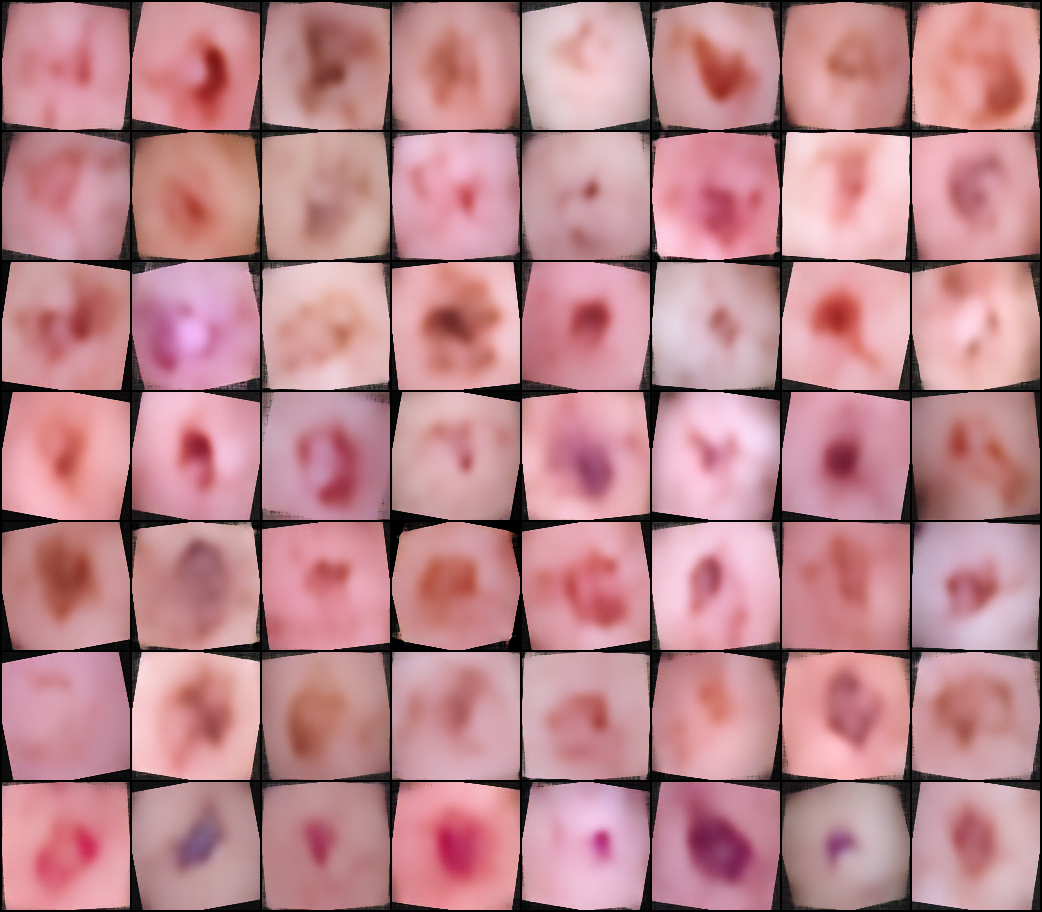

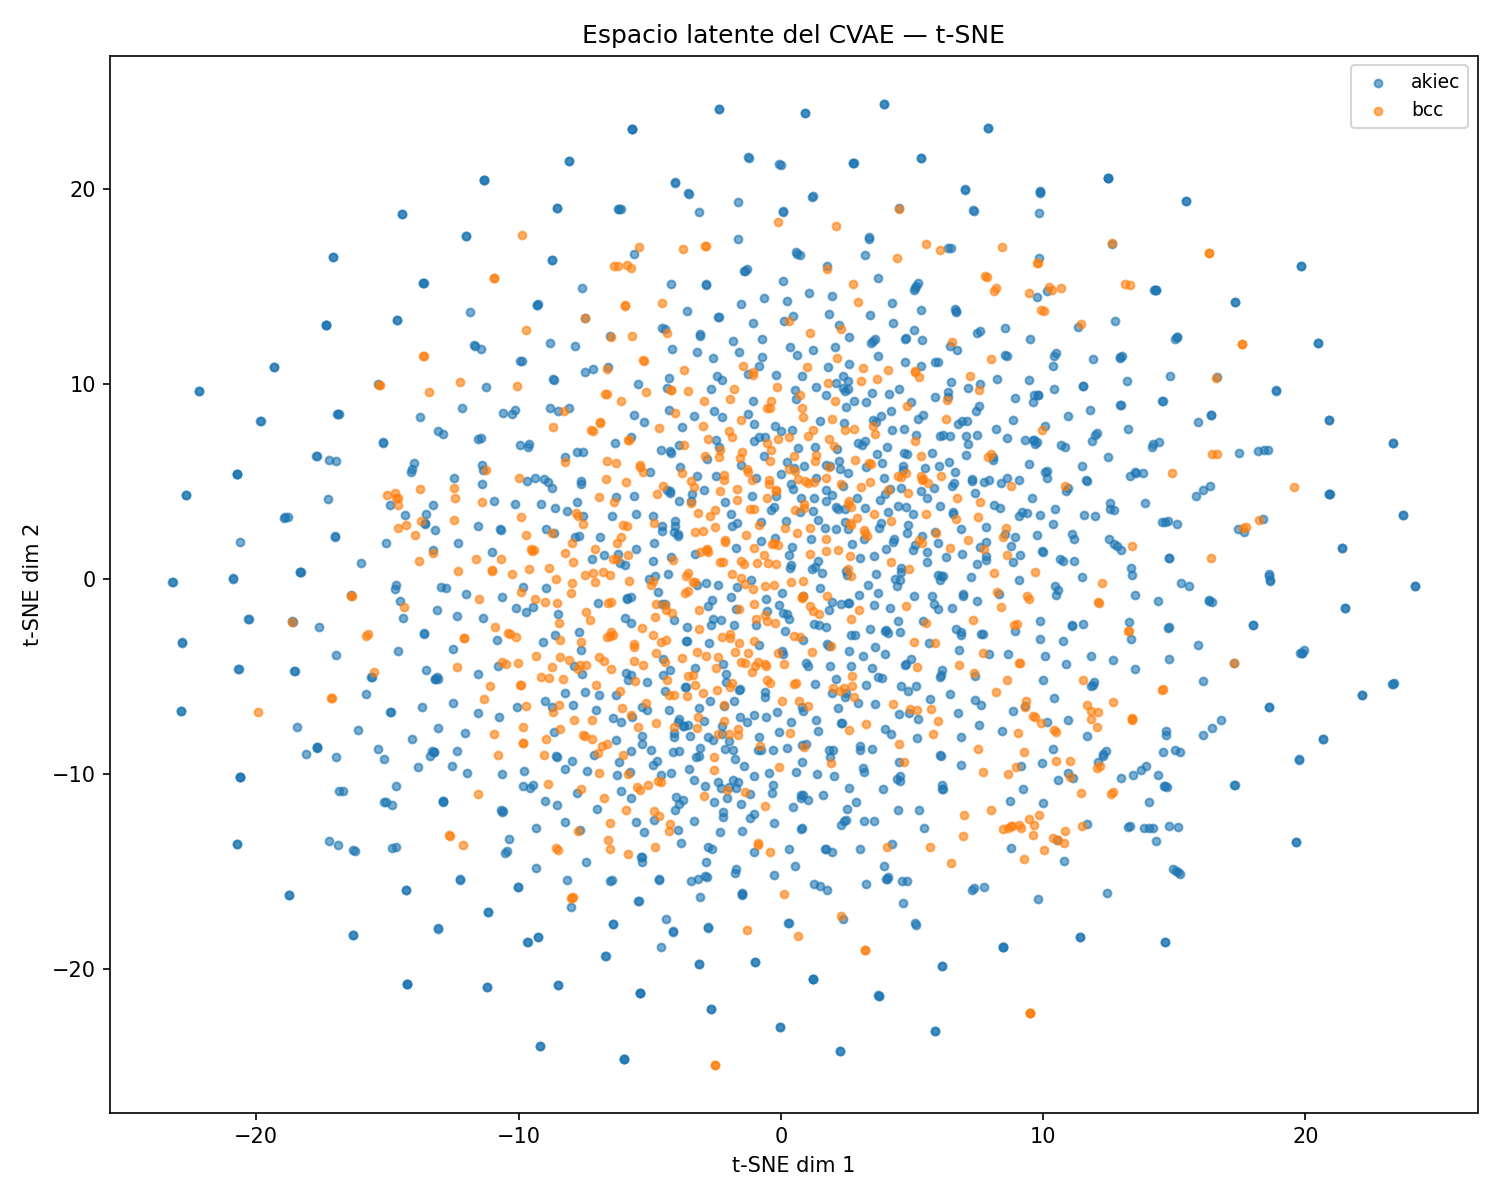

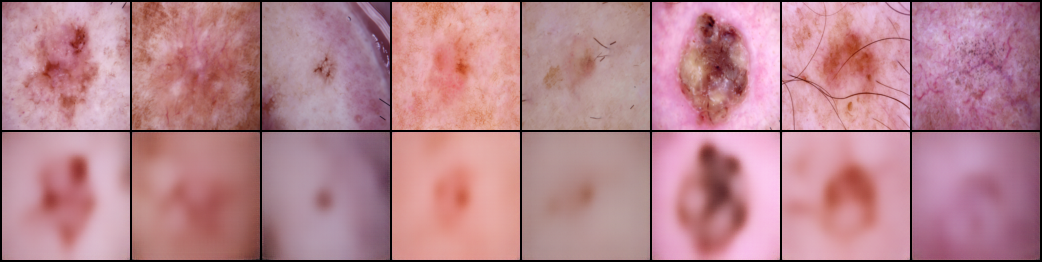

In [ ]:
from IPython.display import Image, display

base = "/content/drive/MyDrive/output_cvae_bce_bn_fp32/eval_output"

display(Image(filename=f"{base}/generated_grid_normalized.png"))
display(Image(filename=f"{base}/latent_tsne.png"))
display(Image(filename=f"{base}/reconstruction_grid_normalized.png"))


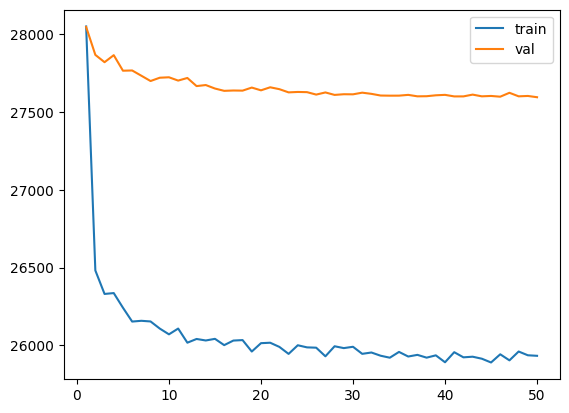

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

log = pd.read_csv('/content/drive/MyDrive/output_cvae_bce_bn_fp32/training_log.csv')

plt.plot(log['epoch'], log['train_loss'], label='train')
plt.plot(log['epoch'], log['val_loss'], label='val')
plt.legend()
plt.savefig('/content/drive/MyDrive/output_cvae_bce_bn_fp32/loss_curve.png')

In [ ]:
!mkdir -p /content/hf_skin_lesion_cvae


In [ ]:
!cp "/content/drive/MyDrive/output_cvae_bce_bn_fp32/code/model_bce_bn.py" \
    "/content/hf_skin_lesion_cvae/model.py"

In [ ]:
!cp "/content/drive/MyDrive/output_cvae_bce_bn_fp32/best_model.pt" \
    "/content/hf_skin_lesion_cvae/best_model.pt"

In [ ]:
import torch
import os

src = "/content/drive/MyDrive/output_cvae_bce_bn_fp32/best_model.pt"
dst = "/content/hf_skin_lesion_cvae/best_model_inference.pt"

ckpt = torch.load(src, map_location="cpu", weights_only=False)

light_ckpt = {
    "model": ckpt["model"],
    "class_names": ckpt.get("class_names", ["akiec", "bcc", "bkl", "df", "mel", "nv", "vasc"]),
    "args": ckpt.get("args", {}),
    "epoch": ckpt.get("epoch", None),
    "best_val": ckpt.get("best_val", None),
}

torch.save(light_ckpt, dst)

print("Checkpoint liviano creado:")
print(dst)
print("Tamaño original:", os.path.getsize(src) / 1024**2, "MB")
print("Tamaño deploy:", os.path.getsize(dst) / 1024**2, "MB")

Checkpoint liviano creado:
/content/hf_skin_lesion_cvae/best_model_inference.pt
Tamaño original: 116.50767517089844 MB
Tamaño deploy: 38.85671424865723 MB


In [ ]:
%%writefile /content/hf_skin_lesion_cvae/requirements.txt
torch
numpy
pillow
huggingface_hub>=0.25.1,<1.0
pydantic==2.10.6

In [ ]:
%%writefile /content/hf_skin_lesion_cvae/app.py
import torch
import gradio as gr
import numpy as np
from PIL import Image

from model import ConditionalVAE


CHECKPOINT_PATH = "best_model_inference.pt"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

DEFAULT_CLASS_NAMES = ["akiec", "bcc", "bkl", "df", "mel", "nv", "vasc"]

CLASS_DESCRIPTIONS = {
    "akiec": "AKIEC — Queratosis actínica / enfermedad de Bowen",
    "bcc": "BCC — Carcinoma basocelular",
    "bkl": "BKL — Lesión benigna tipo queratosis",
    "df": "DF — Dermatofibroma",
    "mel": "MEL — Melanoma",
    "nv": "NV — Nevus melanocítico",
    "vasc": "VASC — Lesión vascular",
}


def load_cvae():
    ckpt = torch.load(CHECKPOINT_PATH, map_location=DEVICE, weights_only=False)

    class_names = ckpt.get("class_names", DEFAULT_CLASS_NAMES)
    args = ckpt.get("args", {})

    latent_dim = int(args.get("latent_dim", 128))
    beta = float(args.get("beta", 1.0))

    model = ConditionalVAE(
        latent_dim=latent_dim,
        num_classes=len(class_names),
        beta=beta,
    ).to(DEVICE)

    model.load_state_dict(ckpt["model"])
    model.eval()

    return model, class_names, ckpt


model, class_names, ckpt = load_cvae()


def tensor_to_pil(img_tensor):
    """
    img_tensor: Tensor (3, H, W) en [0, 1]
    """
    img = img_tensor.detach().cpu().clamp(0, 1)
    img = img.permute(1, 2, 0).numpy()
    img = (img * 255).astype(np.uint8)
    return Image.fromarray(img)


@torch.no_grad()
def generate_images(class_name, temperature, n_images):
    class_idx = class_names.index(class_name)

    imgs = model.generate(
        class_label=class_idx,
        n=int(n_images),
        device=DEVICE,
        temperature=float(temperature),
    )

    return [tensor_to_pil(imgs[i]) for i in range(imgs.size(0))]


def class_info(class_name):
    return CLASS_DESCRIPTIONS.get(class_name, class_name)


description = f"""
# CVAE — Generación sintética de lesiones de piel

Este demo genera imágenes sintéticas de lesiones dermatológicas usando un Conditional VAE entrenado sobre 7 clases.

**Modelo:** Conditional Variational Autoencoder
**Checkpoint epoch:** {ckpt.get("epoch", "N/A")}
**Best val loss:** {ckpt.get("best_val", "N/A")}

**Clases:** {", ".join(class_names)}

⚠️ Demo académico. No usar para diagnóstico médico.
"""


with gr.Blocks(title="Skin Lesion CVAE") as demo:
    gr.Markdown(description)

    with gr.Row():
        with gr.Column():
            class_name = gr.Dropdown(
                choices=class_names,
                value=class_names[0],
                label="Clase de lesión",
            )

            class_description = gr.Textbox(
                value=class_info(class_names[0]),
                label="Descripción",
                interactive=False,
            )

            temperature = gr.Slider(
                minimum=0.2,
                maximum=1.5,
                value=0.8,
                step=0.1,
                label="Temperatura",
            )

            n_images = gr.Slider(
                minimum=1,
                maximum=8,
                value=4,
                step=1,
                label="Número de imágenes",
            )

            btn = gr.Button("Generar imágenes")

        with gr.Column():
            gallery = gr.Gallery(
                label="Imágenes sintéticas generadas",
                columns=4,
                height="auto",
            )

    class_name.change(
        fn=class_info,
        inputs=class_name,
        outputs=class_description,
    )

    btn.click(
        fn=generate_images,
        inputs=[class_name, temperature, n_images],
        outputs=gallery,
    )


if __name__ == "__main__":
    demo.launch()

Writing /content/hf_skin_lesion_cvae/app.py


In [ ]:
%%writefile /content/hf_skin_lesion_cvae/README.md
---
title: Skin Lesion CVAE
emoji: 🔬
colorFrom: blue
colorTo: purple
sdk: gradio
sdk_version: 5.27.0
python_version: '3.12'
app_file: app.py
pinned: false
---

# Skin Lesion CVAE

Demo académico de generación sintética de lesiones dermatológicas usando un Conditional Variational Autoencoder.

## Clases

- akiec
- bcc
- bkl
- df
- mel
- nv
- vasc

## Nota médica

Este Space es solo para fines educativos y de investigación. No debe usarse para diagnóstico clínico.

Writing /content/hf_skin_lesion_cvae/README.md


FileNotFoundError: [Errno 2] No such file or directory: '/content/hf_skin_lesion_cvae/README.md'

In [ ]:
!ls -lh /content/hf_skin_lesion_cvae

total 156M
-rw-r--r-- 1 root root 3.7K Apr 30 16:05 app.py
-rw-r--r-- 1 root root  39M Apr 30 16:05 best_model_inference.pt
-rw------- 1 root root 117M Apr 30 16:04 best_model.pt
-rw------- 1 root root  12K Apr 30 16:04 model.py
-rw-r--r-- 1 root root  454 Apr 30 16:05 README.md
-rw-r--r-- 1 root root   38 Apr 30 16:05 requirements.txt


In [ ]:
%cd /content/hf_skin_lesion_cvae
!python app.py

/content/hf_skin_lesion_cvae
* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.
Keyboard interruption in main thread... closing server.
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/gradio/blocks.py", line 3043, in block_thread
    time.sleep(0.1)
KeyboardInterrupt

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/content/hf_skin_lesion_cvae/app.py", line 148, in <module>
    demo.launch()
  File "/usr/local/lib/python3.12/dist-packages/gradio/blocks.py", line 2950, in launch
    self.block_thread()
  File "/usr/local/lib/python3.12/dist-packages/gradio/blocks.py", line 3047, in block_thread
    self.server.close()
  File "/usr/local/lib/python3.12/dist-packages/gradio/http_server.py", line 69, in close
    self.thread.join(timeout=5)
  File "/usr/lib/python3.12/threading.py", line 1153, in join
    self._wait_for_tstate_lock(timeou

In [ ]:
!pip -q install huggingface_hub

In [ ]:
from huggingface_hub import notebook_login
notebook_login()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [ ]:
from huggingface_hub import upload_folder

repo_id = "Chencho98/DeepLearning"

upload_folder(
    folder_path="/content/hf_skin_lesion_cvae",
    repo_id=repo_id,
    repo_type="space",
    ignore_patterns=[
        "best_model.pt",   # usamos best_model_inference.pt
        "__pycache__/*",
        "*.pyc",
    ],
)

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...e/best_model_inference.pt:   1%|1         |  552kB / 40.7MB            

CommitInfo(commit_url='https://huggingface.co/spaces/Chencho98/DeepLearning/commit/63e3bc66a7aa43017eba9f815c712ec5fdef5f5d', commit_message='Upload folder using huggingface_hub', commit_description='', oid='63e3bc66a7aa43017eba9f815c712ec5fdef5f5d', pr_url=None, repo_url=RepoUrl('https://huggingface.co/spaces/Chencho98/DeepLearning', endpoint='https://huggingface.co', repo_type='space', repo_id='Chencho98/DeepLearning'), pr_revision=None, pr_num=None)

In [ ]:
import shutil

shutil.make_archive(
    '/content/drive/MyDrive/resultados',
    'zip',
    '/content/drive/MyDrive/output_cvae_bce_bn_fp32'
)

'/content/drive/MyDrive/resultados.zip'

In [ ]:
from google.colab import files

files.download('/content/resultados.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>